<a href="https://colab.research.google.com/github/Gautham747/Intermediate-Assessment---2-/blob/main/Intermediate_Assessment__2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [536]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,roc_curve,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Data Loading

In [537]:
df=pd.read_csv('/content/drive/MyDrive/ML AI ICT/Datasets/heart_disease.csv')

## Checking For missing values

In [538]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


##Checking for duplicate Values

In [539]:
df.duplicated().sum()

np.int64(723)

##Droping Duplicate Values

In [540]:
df = df.drop_duplicates()

In [541]:
df.duplicated().sum()

np.int64(0)

In [542]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [543]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [544]:
df["sex"].unique()

array([1, 0])

In [545]:
df["fbs"].unique()

array([0, 1])

In [546]:
df["thal"].unique()

array([3, 2, 1, 0])

## One Hot encoding for chest pain type, resting electrocardiographic results, thal

In [547]:
col_one_hot=["cp","thal","restecg"]
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_data = encoder.fit_transform(df[col_one_hot])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(col_one_hot),
    index=df.index
)

df = df.drop(columns=col_one_hot)

df = pd.concat([df, encoded_df], axis=1)

In [548]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,restecg_0,restecg_1,restecg_2
0,52,1,125,212,0,168,0,1.0,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,53,1,140,203,1,155,1,3.1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,70,1,145,174,0,125,1,2.6,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,61,1,148,203,0,161,0,0.0,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,62,0,138,294,1,106,0,1.9,1,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Correlation Matrix

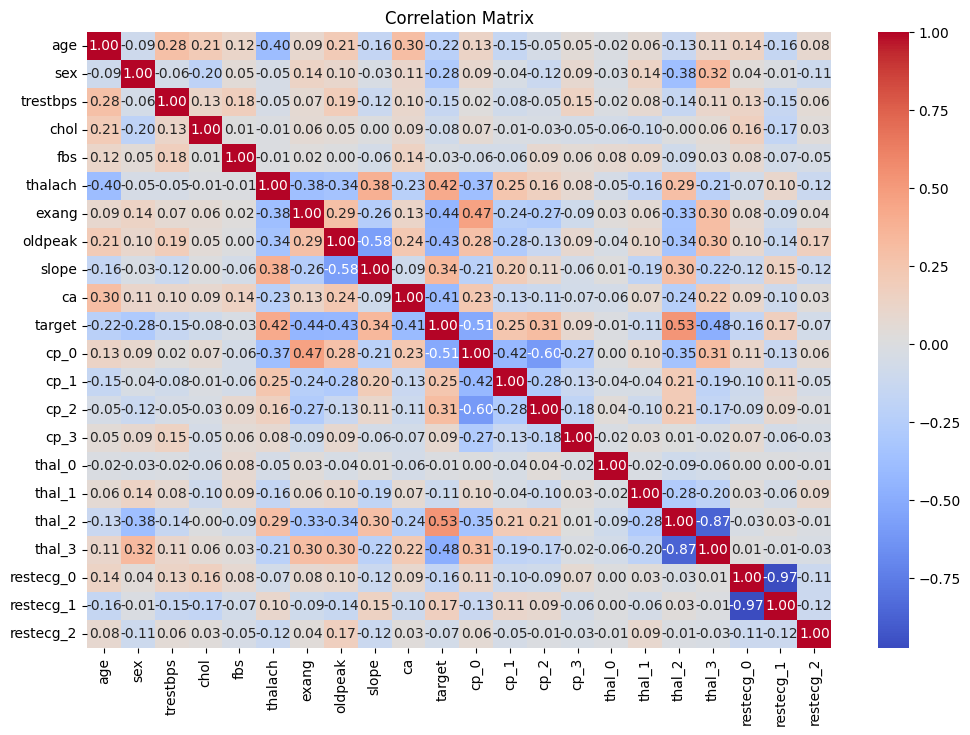

In [549]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

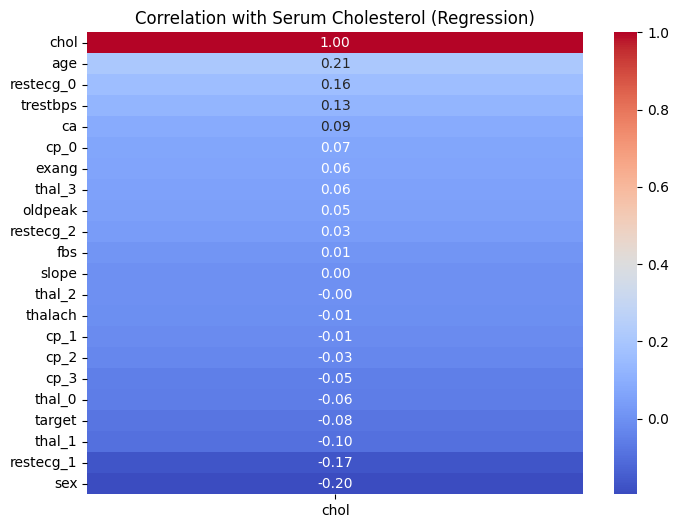

In [550]:
import matplotlib.pyplot as plt
import seaborn as sns

reg_corr = df.corr(numeric_only=True)["chol"].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(
    reg_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Serum Cholesterol (Regression)")
plt.show()

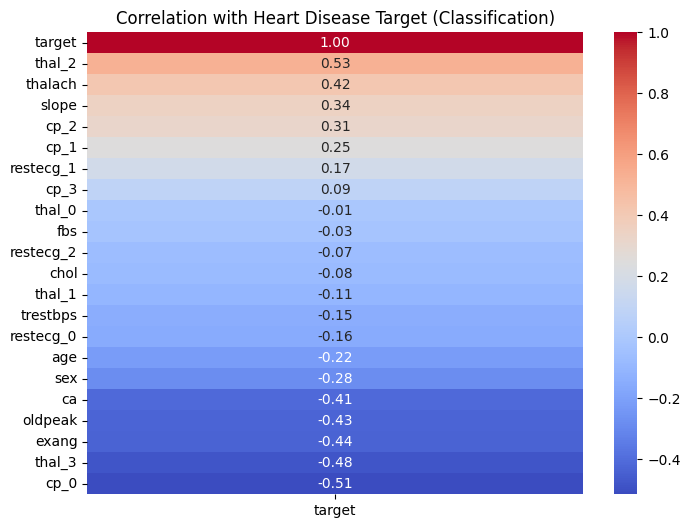

In [551]:
class_corr = df.corr(numeric_only=True)["target"].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(
    class_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Heart Disease Target (Classification)")
plt.show()

##Ploting outliers for regression

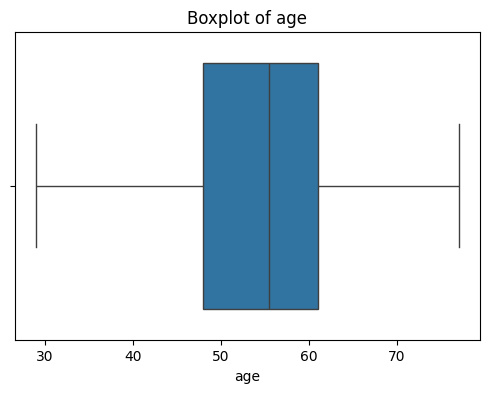

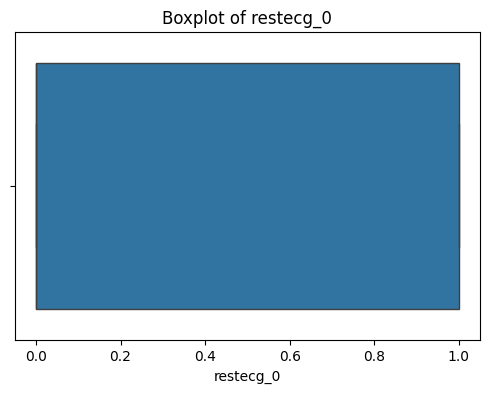

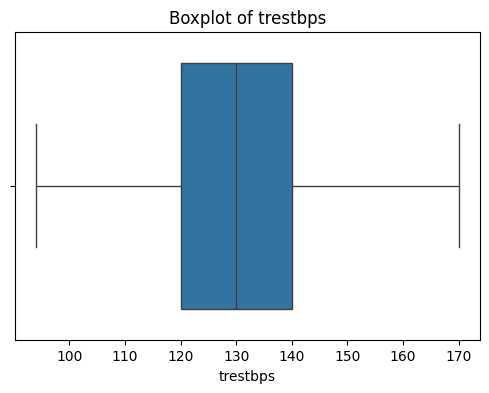

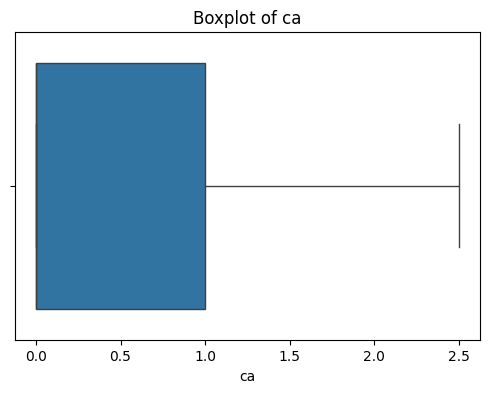

In [565]:
outlier_cols = ["age", "restecg_0","trestbps","ca"]

for col in outlier_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

##Handle Outliers for Regression

In [553]:
# Outlier handling using IQR

outlier_cols = ["age", "restecg_0","trestbps","ca"]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [554]:
reg_features = [
    "age",


]
class_features=["thal_2", "thalach"]

## Spliting features for regression and classification

In [555]:
# Regression
X_reg = df[reg_features]
y_reg = df["chol"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification
X_class = df[class_features]
y_class = df["target"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

## Scaling

In [556]:

scaler_reg = StandardScaler()

X_train_reg[reg_features] = scaler_reg.fit_transform(
    X_train_reg[reg_features]
)

X_test_reg[reg_features] = scaler_reg.transform(
    X_test_reg[reg_features]
)

In [557]:

scaler_class = StandardScaler()

X_train_class[class_features] = scaler_class.fit_transform(
    X_train_class[class_features]
)

X_test_class[class_features] = scaler_class.transform(
    X_test_class[class_features]
)

## Model Training (Regression)

In [558]:
# Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)

# SVR Regression
svm_reg = SVR()
svm_reg.fit(X_train_reg, y_train_reg)

# Random Forest Regression
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(random_state=42)

## Model Training (Classification)

In [559]:
# Logistic Regression
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_class, y_train_class)

# KNN
knn_class = KNeighborsClassifier(n_neighbors=5)
knn_class.fit(X_train_class, y_train_class)

# Random Forest Classification
rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_class.fit(X_train_class, y_train_class)

RandomForestClassifier(random_state=42)

## Model Evaluation (Regression)

In [560]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_lr_reg = lr_reg.predict(X_test_reg)
y_pred_svm_reg = svm_reg.predict(X_test_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

# Linear Regression
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_lr_reg))
print("R²:", r2_score(y_test_reg, y_pred_lr_reg))

# SVM Regression
print("\nSVM Regression")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_svm_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_svm_reg))
print("R²:", r2_score(y_test_reg, y_pred_svm_reg))

# Random Forest Regression
print("\nRandom Forest Regression")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_rf_reg))
print("R²:", r2_score(y_test_reg, y_pred_rf_reg))

Linear Regression
MAE: 32.77024885468831
MSE: 1798.7168372161163
R²: 0.019433205636784634

SVM Regression
MAE: 32.00497406687755
MSE: 1774.0841196238
R²: 0.032861681106739815

Random Forest Regression
MAE: 36.006066145496
MSE: 2068.7242966800304
R²: -0.12776080706310045


## Model Evaluation (Classification)

In [561]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred_lr_class = lr_class.predict(X_test_class)
y_pred_knn_class = knn_class.predict(X_test_class)
y_pred_rf_class = rf_class.predict(X_test_class)

# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test_class, y_pred_lr_class))
print("Precision:", precision_score(y_test_class, y_pred_lr_class))
print("Recall:", recall_score(y_test_class, y_pred_lr_class))
print("F1-Score:", f1_score(y_test_class, y_pred_lr_class))

# KNN
print("\nKNN")
print("Accuracy:", accuracy_score(y_test_class, y_pred_knn_class))
print("Precision:", precision_score(y_test_class, y_pred_knn_class))
print("Recall:", recall_score(y_test_class, y_pred_knn_class))
print("F1-Score:", f1_score(y_test_class, y_pred_knn_class))

# Random Forest
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf_class))
print("Precision:", precision_score(y_test_class, y_pred_rf_class))
print("Recall:", recall_score(y_test_class, y_pred_rf_class))
print("F1-Score:", f1_score(y_test_class, y_pred_rf_class))

Logistic Regression
Accuracy: 0.7868852459016393
Precision: 0.7777777777777778
Recall: 0.8484848484848485
F1-Score: 0.8115942028985508

KNN
Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878
F1-Score: 0.7878787878787878

Random Forest
Accuracy: 0.6885245901639344
Precision: 0.71875
Recall: 0.696969696969697
F1-Score: 0.7076923076923077


## Saving the best model

In [569]:
import joblib

# Save best regression model
best_model = svm_reg

with open("best_regression_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

# Load regression model
with open("best_regression_model.pkl", "rb") as file:
    best_model = joblib.load(file)

# Regression prediction
y_pred_reg = best_model.predict(X_test_reg)


# Save best classification model
best_model = lr_class

with open("best_classification_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

# Load classification model
with open("best_classification_model.pkl", "rb") as file:
    best_model = joblib.load(file)

# Classification prediction
y_pred_class = best_model.predict(X_test_class)

In [570]:
best_model = lr_class

with open("best_classification_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

with open("best_classification_model.pkl", "rb") as file:
    best_model = joblib.load(file)

y_pred_class = best_model.predict(X_test_class)